    Bernacchia Alessia, Pioda Tommaso, Villani Giacomo
    Data Project and Hackaton 3
    _Sandra Mitròvich_

In [ ]:
import pandas as pd
import numpy as np
import pyarrow as pa
from matplotlib import pyplot as plt
import os
import re
import glob
from datetime import datetime
import pyarrow.parquet as pq
from tqdm.auto import tqdm
tqdm.pandas()

os.makedirs("data", exist_ok=True)

RANDOM_SEED = 42

# path to the Parquet files folder
PARQUET_PATH = "data/parquet"
CLEANED_DATA_PATH = "data/cleaned_parquet"
SPLIT_DATA_PATH = "data/split"

# Values that should be treated as NaN/None
NULL_PLACEHOLDERS = ['None', 'nan', 'NaN', 'N/A', '', '-', '/', '?', 'null']

# path where safe utils
AUTH_REGISTRY_PATH = "data/authors_registry.parquet"
RAW_AUTH_REGISTRY_PATH = "data/authors_registry_full.parquet"
ID_REGISTRY_PATH = "data/ids_registry.parquet"

# checkpointing parameters
CHECKPOINTS_PATH = "data/checkpoints"
SAVE_CHECKPOINTS = False  # Set to True to save checkpoints during processing

In [2]:
# extract parquet files
parquet_folder = os.path.abspath(PARQUET_PATH)
print(f'The parquet files are saved in : {parquet_folder}')
parquet_files = [f for f in os.listdir(parquet_folder) if f.endswith('.parquet')]

print(f"Total Parquet files found: {len(parquet_files)}")


# function to obtain the path of a file given the index
parquet_file_path_n = lambda n: os.path.join(parquet_folder, parquet_files[n])
# function to convert a parquet to a table or to a pandas dataframe
parquet_to_table = lambda parquet_path: pq.read_table(parquet_path)
parquet_to_df = lambda parquet_path: pq.read_table(parquet_path).to_pandas()

# efficiently peek at just the first N rows of a file
def peek_file(n, rows=5):
    path = parquet_file_path_n(n)
    return parquet_to_table(path).slice(0, rows).to_pandas()

# load the full schema/columns only (to verify consistency)
def get_schema(n=0):
    return pq.read_schema(parquet_file_path_n(n))

def stream_all_data():
    """Generator to yield one DataFrame at a time from all parquet files."""
    for i in range(len(parquet_files)):
        yield pd.read_parquet(parquet_file_path_n(i))

The parquet files are saved in : c:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1\data\parquet
Total Parquet files found: 68


In [3]:
class DBLP_Loader:
    """ Loader class to handle the streaming and processing of the DBLP dataset.
    - Initializes with the folder path containing the parquet files.
    - Provides methods to load all data at once (with caution) or to stream and process files one by one.
    - Includes a specific method to fill missing author details using an authors registry.
    - Offers a safe checkpointing method to save processed data in chunks to avoid memory issues."""
    def __init__(self, folder_path):
        self.folder = os.path.abspath(folder_path)
        
        self.files = sorted([f for f in os.listdir(self.folder) if f.endswith('.parquet')])
        self.current_data = []

        # column types lists for processing and checkpointing
        self.string_columns = []
        self.numeric_columns = []
        self.array_of_str_columns = []
        self.array_of_dict_columns = []  

    def get_full_df(self):
        """Loads all files into one DataFrame (Careful with RAM!)"""
        all_chunks = []
        for f in tqdm(self.files, desc="Loading Parquet Files"):
            path = os.path.join(self.folder, f)
            all_chunks.append(pd.read_parquet(path))
        return pd.concat(all_chunks, ignore_index=True)
    
    def stream_and_process(self, process_func, update_internal=True, take_current=True, **kwargs):
        """Processes files one by one and optionally updates internal state."""
        results = []

        if take_current and self.current_data:
            print("Processing current internal data...")
            for c in tqdm(self.current_data, desc="Processing Current Data Chunks"):
                processed_chunk = process_func(c, **kwargs)
                results.append(processed_chunk)
        
        elif take_current or not self.current_data:
            print("No current internal data to process, streaming from files...")
            for f in tqdm(self.files, desc="Processing Batches"):
                path = os.path.join(self.folder, f)
                df = pd.read_parquet(path)
                processed_df = process_func(df, **kwargs)
                results.append(processed_df)

        if update_internal == True:
            self.current_data = results

        return results
    
    def fill_author_gaps(self, author_registry, chunks=None, update_internal=True):
        """
        Specific process function to fill missing author details.
        - Fills missing `id` from `official_name`.
        - Fills missing `official_name` from `id`.
        - Fills missing `org` from `id` and `year`.
        """
        chunks = chunks if chunks is not None else self.current_data  
        reg = author_registry.copy()

        # mapping
        print("Creating mapping dictionaries from the authors registry...")

        print("\tname to official name mapping...")
        # name -> official_name
        # name_to_official_name = reg.explode('name').set_index('name')['official_name'].to_dict()
        name_exploded = reg.explode('name', ignore_index=True)
        name_to_official_name = dict(zip(name_exploded['name'].values, name_exploded['official_name'].values))
        
        print("\tid to official name mapping...")
        # id -> official_name
        # name_to_id = reg.set_index('official_name')['id'].to_dict()
        name_to_id = dict(zip(reg['official_name'].values, reg['id'].values))

        print("\tofficial name to id mapping...")
        # official_name -> id
        # id_to_name = reg.set_index('id')['official_name'].to_dict()
        id_to_name = dict(zip(reg['id'].values, reg['official_name'].values))

        print("\tid-year to org mapping...")
        # id, year -> org
        def valid_format_org_year(cell):
            if isinstance(cell, dict) and 'org' in cell and 'year' in cell:
                return True  # Wrap in a list to standardize the format
            else:
                if isinstance(cell, list) and len(cell) == 2 and isinstance(cell[0], str) and isinstance(cell[1], (int, float)):
                    print(f"Warning: 'org_year' is a list instead of dict. Converting to dict format for consistency.")
                return False  # Invalid format, will be filtered out later

        registry_exploded = reg.explode('org_year', ignore_index=True)
        # filter out rows where 'org_year' is not a valid dict
        mask_valid = registry_exploded['org_year'].map(valid_format_org_year)
        registry_exploded = registry_exploded[mask_valid]
        # divide 'org_year' in two different columns, 'org' and 'year'
        org_year_df = pd.json_normalize(registry_exploded['org_year']) # json normalization is faster
        registry_exploded = pd.concat([registry_exploded[['id']], org_year_df[['org', 'year']]]
                                      , axis=1).dropna(subset=['org', 'year', 'id'])

        # convert types for memory efficiency
        registry_exploded['year'] = registry_exploded['year'].astype('int32', errors='ignore')
        registry_exploded['org'] = registry_exploded['org'].astype('category')


        id_year_to_org = dict(zip(zip(registry_exploded['id'].values, registry_exploded['year'].values),
                                  registry_exploded['org'].values))
        
        del reg, org_year_df, registry_exploded, name_exploded  # free memory

        # function to fill the gaps in the authors data
        def fill_missing(authors, year):
            if authors is None or not isinstance(authors, list) or len(authors) == 0:
                return authors  # No authors to process, skip to next row
            
            for a in authors:
                if a is None or pd.isna(a) or not isinstance(a, dict):
                    continue  # Skip invalid author entries
                
                name = a.get('name')
                a_id = a.get('id')

                if name and name in name_to_official_name:
                    official_name = name_to_official_name.get(name)
                    a['name'] = official_name

                    # no ID, but official name is known
                    if pd.isna(a_id) and official_name in name_to_id:
                        a['id'] = name_to_id.get(official_name)

                # no name, but ID is known
                elif pd.isna(name) and a_id in id_to_name:
                    a['name'] = id_to_name.get(a_id)

                # not org, but ID and year are known
                if pd.isna(a.get('org')) and a_id and isinstance(year, (int, float)) and (a_id, year) in id_year_to_org:
                    a['org'] = id_year_to_org.get((a_id, year))

            return authors
        
        # process chunks
        results = []
        for c in tqdm(chunks, desc="Filling Authors Gaps Chunks:"):
            c = c.copy()
            # fill missing values
            c['authors'] = [fill_missing(authors, year) for authors, year in zip(c['authors'], c['year'])]
            
            results.append(c)

        if update_internal == True:
            self.current_data = results

        return results
    
    def fix_venue_mismatch(self, chunks=None, update_internal=True):
        """ Checks for mismatches between 'venue' and 'doc_type' and attempts to fix them based on simple heuristics in every chunk."""
        chunks = chunks if chunks is not None else self.current_data
        results = []

        n_conf_as_journ = 0
        n_journ_as_conf = 0
        n_no_doc_type_conf_venue = 0
        n_no_doc_type_journ_venue = 0
        
        def check_and_fix_venue_mismatch(df):
            """ Checks for mismatches between 'venue' and 'doc_type' and attempts to fix them based on simple heuristics."""
            # Example: If 'Conference' in venue name but 'Journal' in doc_type, set doc_type to 'Conference'
            conf_as_journ = (df['venue'].str.contains('Conference', case=False, na=False)) & (df['doc_type'].str.contains('Journal', case=False, na=False))
            journ_as_conf = (df['venue'].str.contains('Journal', case=False, na=False)) & (df['doc_type'].str.contains('Conference', case=False, na=False))
            no_doc_type_conf_venue = (df['doc_type'].isna()) & (df['venue'].str.contains('Conference', case=False, na=False))
            no_doc_type_journ_venue = (df['doc_type'].isna()) & (df['venue'].str.contains('Journal', case=False, na=False))

            n_conf_as_journ = conf_as_journ.sum()
            n_journ_as_conf = journ_as_conf.sum()
            n_no_doc_type_conf_venue = no_doc_type_conf_venue.sum()
            n_no_doc_type_journ_venue = no_doc_type_journ_venue.sum()
            
            df.loc[conf_as_journ, 'doc_type'] = 'conference'
            df.loc[journ_as_conf, 'doc_type'] = 'journal'
            df.loc[no_doc_type_conf_venue, 'doc_type'] = 'conference'
            df.loc[no_doc_type_journ_venue, 'doc_type'] = 'journal'

            return df, n_conf_as_journ, n_journ_as_conf, n_no_doc_type_conf_venue, n_no_doc_type_journ_venue
        
        for c in tqdm(chunks, desc="Fixing Venue Mismatch Chunks:"):
            c = c.copy()
            c, n1, n2, n3, n4 = check_and_fix_venue_mismatch(c)
            
            n_conf_as_journ += n1
            n_journ_as_conf += n2
            n_no_doc_type_conf_venue += n3
            n_no_doc_type_journ_venue += n4

            results.append(c)
        
        if update_internal == True:
            self.current_data = results

        print(f"Found and fixed {n_conf_as_journ} mismatches where 'Conference' is in venue but doc_type is 'Journal'.")
        print(f"Found and fixed {n_journ_as_conf} mismatches where 'Journal' is in venue but doc_type is 'Conference'.")
        print(f"Found and fixed {n_no_doc_type_conf_venue} mismatches where 'Conference' is in venue but doc_type is missing.")
        print(f"Found and fixed {n_no_doc_type_journ_venue} mismatches where 'Journal' is in venue but doc_type is missing.")

        return results
    
    def set_column_types(self, string_cols, numeric_cols, array_of_str_cols, array_of_dict_cols):
        """
        Set the column types for processing and checkpointing.
        This method allows us to define which columns are of which type, so that we can apply the appropriate processing and ensure consistent schema when saving to Parquet."""
        self.string_columns = string_cols
        self.numeric_columns = numeric_cols
        self.array_of_str_columns = array_of_str_cols
        self.array_of_dict_columns = array_of_dict_cols

    def pyarrow_schema_from_df(self, data):
        """
        Generates a PyArrow schema based on the columns present in the DataFrame.
        This is used to ensure that when we save to Parquet, we maintain consistent data types and structure.
        """
        fields = []
        for col in self.string_columns:
            if col in data.columns:
                fields.append(pa.field(col, pa.string()))

        for col in self.numeric_columns:
            if col in data.columns:
                fields.append(pa.field(col, pa.float64()))

        for col in self.array_of_str_columns:
            if col in data.columns:
                fields.append(pa.field(col, pa.list_(pa.string())))

        for col in self.array_of_dict_columns:
            if col in data.columns:
                if col == 'authors':
                    # Definiamo i campi fissi dello struct per gli autori
                    author_struct = pa.struct([
                        pa.field('id', pa.string()),
                        pa.field('name', pa.string()),
                        pa.field('org', pa.string())
                    ])
                    fields.append(pa.field(col, pa.list_(author_struct)))
                else:
                    pass
                    # fields.append(pa.field(col, pa.list_(pa.struct([pa.field(k, pa.string()) for k in v.keys()]))))

        return pa.schema(fields)
    
    def safe_checkpoint(self, base_name='01_cleaned_data', path='data/checkpoints', chunk_size = 100000, mode_divide_by=False):
        """
        Save the processed data to Parquet files in chunks.
        Parameters:
            - data: DataFrame to save
            - path: Directory where to save the Parquet files
            - base_name: The base name for the saved files
        """
        if not os.path.exists(path):
            os.makedirs(path)
        
        data = pd.concat(self.current_data, ignore_index=True)

        # print("Replacing null placeholders with NaN for checkpointing...")
        # for col in data.columns:
        #     data[col] = data[col].astype(str).replace(NULL_PLACEHOLDERS, np.nan)

        # print("Forcing column types for checkpointing...")
        # for col in self.numeric_columns:
        #     if col in data.columns:
        #         data[col] = pd.to_numeric(data[col], errors='coerce')
                
        # for col in self.array_of_str_columns + self.array_of_dict_columns:
        #     if col in data.columns:
        #         try:
        #             data[col] = data[col].apply(lambda x: list(x))
        #         except Exception as e:
        #             print(f"Error occurred while processing column {col}: {e}")
        
        print("Retrieving PyArrow schema for checkpointing...")
        schema = self.pyarrow_schema_from_df(data)
        print(f"\nGenerated PyArrow schema for checkpointing: \n{schema}\n")
        print(f"Saving checkpoint with {len(data)} records...")
        if mode_divide_by:
            col = mode_divide_by
            # If mode_divide_by is active, we will save one file per each value in the column specified (e.g., 'year'), instead of splitting by chunk size.
            unique_values = data[col].dropna().unique()
            unique_values.sort()

            for value in tqdm(unique_values, desc="Saving Parquet Files by Value"):
                value_data = data[data[col] == value]
                file_path = os.path.join(path, f"{base_name}_{value}.parquet")
                value_data.to_parquet(file_path, engine='pyarrow', schema=schema, index=False)

            print(f"Checkpoint saved to {path} with files divided by {col}.")
            return
        
        else:
            # Split data into smaller chunks and save each as a Parquet file
            total_chunks = len(data) // chunk_size + (len(data) % chunk_size > 0)
            
            for i in tqdm(range(total_chunks), desc="Saving Parquet Files"):
                start_idx = i * chunk_size
                end_idx = min((i + 1) * chunk_size, len(data))
                
                chunk = data.iloc[start_idx:end_idx]
                file_path = os.path.join(path, f"{base_name}_part_{i + 1}.parquet")
                chunk.to_parquet(file_path, engine='pyarrow', schema=schema, index=False)

            print(f"Checkpoint saved to {path}")

In [4]:
loader = DBLP_Loader(PARQUET_PATH)
loader.stream_and_process(lambda df: df)  # just to initialize internal state with the schema
print(f"Ready to process {len(loader.files)} files.")

No current internal data to process, streaming from files...


Processing Batches:   0%|          | 0/68 [00:00<?, ?it/s]

Ready to process 68 files.


# A - Exploration and Cleaning of the Dataset

## 0. Overview: DBLP Citation Network


### 0.1 Description

The dataset is a comprehensive collection of scientific papers sourced from the DBLP (Computer Science Bibliography). 

It is designed for tasks involving data exploration, citation prediction, and classification within the academic domain.

Source: [DBLP (Computer Science Bibliography)](https://opendata.aminer.cn/dataset/DBLP-Citation-network-V18.zip)

Size: 6.7 million papers

Format: JSONL (JSON Lines) file

### 0.2 Key Data Fields:

In [5]:
# column groups based on categories
NUMERIC_COLS = ['year', 'n_citation', 'page_start', 'page_end', 'volume', 'issue']
STRING_COLS = ['id', 'title', 'lang', 'doc_type', 'venue', 'issn', 'isbn', 'doi', 'abstract']
ARRAY_OF_STR_COLS = ['references', 'keywords', 'url']
ARRAY_OF_DICT_COLS = ['authors']

loader.set_column_types(string_cols=STRING_COLS, numeric_cols=NUMERIC_COLS, array_of_str_cols=ARRAY_OF_STR_COLS, array_of_dict_cols=ARRAY_OF_DICT_COLS)


- **id** (_string_): unique identifier for the paper, mix of alpha characters and numbers.
- **title** (_string_): title of the research paper.
- **year** (_integer_): year of publication.
- **authors** (_list_): including author name, id, and affiliation (org).
- **lang** (_string_): detected language of the text.
- **doc_type** (_string_ [conference, journal]): categorization one between `conference` or `journal`.
- **venue** (_string_): the conference or journal where it was published.
- **references** (_list_): paper IDs cited by this document.
- **keywords** (_list_): relevant tags or index terms.
- **abstract** (_string_): summary of the paper's content.
- **n_citation** (_integer_): number of received citations.
---
- **page_start** (_integer_): starting page number in publication.
- **page_end** (_integer_): ending page number in publication.
- **volume** (_integer_): volume number of the publication.
- **issue** (_integer_): issue number of the publication.
- **issn** (_string_): International Standard Serial Number.
- **isbn** (_string_): International Standard Book Number.
- **doi** (_string_): Digital Object Identifier link, mix of alpha characters and numbers.
- **url** (_list_): link to external web resources.

## 1. Exploration

### of the first 1000 lines in chunk 0

In [6]:
# extract files
# tab_0 = parquet_to_table(parquet_file_path_n(0))
# df_0 = tab_0.slice(0, 3).to_pandas()
# df_0.head(3)
peek_file(0, rows=3)

,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,,"[First Page, 3-D Mechanical Object Shapes, Eng...",1984,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...","[5390962020f70186a0df3bf2, 5390879d20f70186a0d...",32,40,en,17,12,0018-9162,,10.1109/mc.1984.1659026,[],46,Computer,Journal
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,The UCI version of the Rand Message Handling S...,"[Computer network mail, Distributed mail syste...",1985,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...",[5390880720f70186a0d7a97e],65,80,en,10,2,0169-7552,,10.1016/0169-7552(85)90077-7,[https://doi.org/10.1016/0169-7552(85)90077-7],4,Computer Networks and ISDN Systems,Journal
2,5390877920f70186a0d2e433,Characterizing an Optimal Input in Perturbed C...,When every feasible stable perturbation of dat...,"[Optimal input, region of stability, input con...",1983,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...","[53e99d28b7602d97025da4e6, 5390877920f70186a0d...",109,121,en,25,1,0025-5610,,10.1007/bf02591721,[https://dl.acm.org/doi/10.5555/9504.9513],20,Mathematical Programming,Journal


In [7]:
def inspect_authors_field(df):
    """Inspect the 'authors' field for potential issues."""
    print("Inspecting 'authors' field for potential issues...")
    # count NaN values
    num_nan = df['authors'].isna().sum()
    print(f"\tNumber of NaN values in 'authors': {num_nan}")

    # validate structure
    def is_valid_author_entry(authors):
        if isinstance(authors, np.ndarray):
            for a in authors:
                if not isinstance(a, dict):
                    return False
                if ('name' not in a) or ('id' not in a) or ('org' not in a):
                    return False
            return True
        return False  # anything else is invalid

    # check for invalid structures
    invalid_structure_mask = ~df['authors'].apply(is_valid_author_entry)
    num_invalid_structures = invalid_structure_mask.sum()
    print(f"\tNumber of entries with invalid structure in 'authors': {num_invalid_structures}")

    # check for empty arrays/lists
    def is_empty_array(authors):
        if isinstance(authors, np.ndarray):
            return len(authors) == 0
        return False

    empty_array_mask = df['authors'].apply(is_empty_array)
    num_empty_arrays = empty_array_mask.sum()
    print(f"\tNumber of empty array entries in 'authors': {num_empty_arrays}")

    exploded = df.explode('authors', ignore_index=True)['authors']
    exploded_names = exploded.apply(lambda a: a.get('name') if isinstance(a, dict) and 'name' in a else np.nan)
    n_unique_authors = exploded_names.dropna().nunique()
    print(f"\tNumber of unique authors in 'authors': {n_unique_authors}")

def inspect_keywords_field(df):
    """Inspect the 'keywords' field for potential issues."""
    print("Inspecting 'keywords' field for potential issues...")
    # count NaN values
    num_nan = df['keywords'].isna().sum()
    print(f"\tNumber of NaN values in 'keywords': {num_nan}")

    # check for empty arrays/lists
    def is_empty_array(keywords):
        if isinstance(keywords, np.ndarray):
            return len(keywords) == 0
        return False

    empty_array_mask = df['keywords'].dropna().apply(is_empty_array)
    num_empty_arrays = empty_array_mask.sum()
    print(f"\tNumber of empty array entries in 'keywords': {num_empty_arrays}")

    # check for invalid structures
    def is_valid_keyword_entry(keywords):
        if isinstance(keywords, np.ndarray) or isinstance(keywords, list):
            return all(isinstance(k, str) for k in keywords)
        return False
    invalid_structure_mask = ~df['keywords'].apply(is_valid_keyword_entry)
    num_invalid_structures = invalid_structure_mask.sum()
    print(f"\tNumber of entries with invalid structure in 'keywords': {num_invalid_structures}")

    # check for number of unique keywords
    unique_keywords = df['keywords'].explode().dropna().nunique()
    print(f"\tNumber of unique keywords: {unique_keywords}")

    # check for number of keywords per paper
    num_keywords = df['keywords'].apply(lambda x: len(x) if isinstance(x, np.ndarray) else 0)
    print(f"\tAverage number of keywords per paper: {num_keywords.mean():.2f}")
    print(f"\tMax number of keywords for a single paper: {num_keywords.max()}")

    # check for most common keywords
    all_keywords = df['keywords'].explode().dropna()
    all_keywords = all_keywords.apply(lambda x: x.strip().lower() if isinstance(x, str) else x)  # normalize keywords
    top_keywords = all_keywords.value_counts().head(10)
    print("\tTop 10 most common keywords:")
    for i, k in enumerate(top_keywords.index):
        print(f"\t\t{i}) {k}: {top_keywords[k]} occurrences")

def inspect_venue_field(df):
    """Inspect the 'venue' field for potential issues."""
    print("Inspecting 'venue' field for potential issues...")
    # count NaN values
    num_nan = df['venue'].isna().sum()
    print(f"\tNumber of NaN values in 'venue': {num_nan}")

    # check for number of unique venues
    n_unique_venues = df['venue'].nunique()
    print(f"\tNumber of unique venues: {n_unique_venues}")

    # check for most common venues
    top_venues = df['venue'].value_counts().head(10)
    print("\tTop 10 most common venues:")
    for i, v in enumerate(top_venues.index):
        print(f"\t\t{i}) {v}: {top_venues[v]} occurrences")

def inspect_doc_type_field(df):
    """Inspect the 'doc_type' field for potential issues."""
    print("Inspecting 'doc_type' field for potential issues...")
    # count NaN values
    num_nan = df['doc_type'].isna().sum()
    print(f"\tNumber of NaN values in 'doc_type': {num_nan}")

    # check for number of unique doc types
    n_unique_doc_types = df['doc_type'].dropna().nunique()
    print(f"\tNumber of unique doc types: {n_unique_doc_types}")

    # check for most common doc types
    top_doc_types = df['doc_type'].value_counts().head(10)
    print("\tTop 10 most common doc types:")
    for i, dt in enumerate(top_doc_types.index):
        print(f"\t\t{i}) {dt}: {top_doc_types[dt]} occurrences")

def inspect_year_field(df):
    """Inspect the 'year' field for potential issues."""
    print("Inspecting 'year' field for potential issues...")
    # count NaN values
    num_nan = df['year'].isna().sum()
    print(f"\tNumber of NaN values in 'year': {num_nan}")

    # check for valid year range
    current_year = datetime.now().year
    invalid_years = df[(df['year'] > current_year) | (df['year'] <= 1800)]['year']
    num_invalid_years = invalid_years.count()
    print(f"\tNumber of invalid years (<=1800 or >{current_year}): {num_invalid_years}")

    # check for most common years
    top_years = df['year'].value_counts().head(10)
    print("\tTop 10 most common publication years:")
    for i, y in enumerate(top_years.index):
        print(f"\t\t{i}) {y}: {top_years[y]} occurrences")

def global_inspection(df):
    df = df.copy()

    # explode properly
    df = df.explode('authors', ignore_index=True)
    df = df.explode('keywords', ignore_index=True)

    # base describe
    df_descr = df.describe(include='all')

    # create rows with same index as df_descr
    dtypes = pd.Series(df.dtypes, name='dtype')
    nan_values = pd.Series(df.isna().sum(), name='num_nan')
    not_nan_values = pd.Series(df.notna().sum(), name='num_not_nan')

    # convert these Series into DataFrames with matching index
    dtypes_df = dtypes.to_frame().T
    nan_df = nan_values.to_frame().T
    not_nan_df = not_nan_values.to_frame().T

    # assign proper index labels
    dtypes_df.index = ['dtype']
    nan_df.index = ['num_nan']
    not_nan_df.index = ['num_not_nan']

    # concatenate vertically
    global_df = pd.concat([nan_df, not_nan_df,df_descr, dtypes_df], axis=0)

    print("Global DataFrame Description:")
    display(global_df)
    return global_df

In [8]:
raw_chunk_0 = peek_file(0, rows=1000)
raw_global_df = global_inspection(raw_chunk_0)

Global DataFrame Description:


,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
num_nan,0,0,0,264,0,0,0,0,0,0,0,0,0,0,0,0,0,201,0
num_not_nan,17801,17801,17801,17537,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17600,17801
count,17801,17801,17801,17537,17801.0,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801.0,17600,17801
unique,1000,1000,979,5743,NaN,2812,1000,576,586,2,158,38,264,24,975,1000,NaN,781,2
top,5390a45620f70186a0e733d1,LAHVA: Linked Animal-Human Health Visual Analy...,Coordinated animal-human health monitoring can...,proposed method,NaN,"{'id': '53f38e3edabfae4b34a44248', 'name': 'Ki...","[53e9a2b3b7602d9702bbdcc3, 53e9a789b7602d97030...",,,en,,,,,,[https://www.semanticscholar.org/paper/afbe068...,NaN,Lecture notes in computer science,Conference
freq,190,190,190,22,NaN,32,190,3103,3440,17564,10615,12471,8771,17006,550,190,NaN,350,11821
mean,NaN,NaN,NaN,NaN,2005.209932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.790068,NaN,NaN
std,NaN,NaN,NaN,NaN,6.838024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.779179,NaN,NaN
min,NaN,NaN,NaN,NaN,1959.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25%,NaN,NaN,NaN,NaN,2003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN


In [9]:
inspect_authors_field(raw_chunk_0)
print()

Inspecting 'authors' field for potential issues...
	Number of NaN values in 'authors': 0
	Number of entries with invalid structure in 'authors': 0
	Number of empty array entries in 'authors': 0
	Number of unique authors in 'authors': 2787



In [10]:
inspect_keywords_field(raw_chunk_0)
print()

Inspecting 'keywords' field for potential issues...
	Number of NaN values in 'keywords': 0
	Number of empty array entries in 'keywords': 98
	Number of entries with invalid structure in 'keywords': 0
	Number of unique keywords: 5743
	Average number of keywords per paper: 6.02
	Max number of keywords for a single paper: 32
	Top 10 most common keywords:
		0) proposed method: 8 occurrences
		1) data mining: 7 occurrences
		2) clustering: 7 occurrences
		3) data structure: 6 occurrences
		4) scheduling: 6 occurrences
		5) neural network: 6 occurrences
		6) new method: 6 occurrences
		7) ontology: 6 occurrences
		8) quality of service: 5 occurrences
		9) optimization: 5 occurrences



In [11]:
inspect_venue_field(raw_chunk_0)
print()

Inspecting 'venue' field for potential issues...
	Number of NaN values in 'venue': 8
	Number of unique venues: 781
	Top 10 most common venues:
		0) Lecture notes in computer science: 13 occurrences
		1) Automatica: 8 occurrences
		2) Theoretical Computer Science: 7 occurrences
		3) Bioinformatics: 7 occurrences
		4) IEEE Transactions on Information Theory: 7 occurrences
		5) Signal Processing: 6 occurrences
		6) IEEE Transactions on Signal Processing: 6 occurrences
		7) Computer: 5 occurrences
		8) IEEE Transactions on Computers: 5 occurrences
		9) Computer Communications: 5 occurrences



In [12]:
inspect_doc_type_field(raw_chunk_0)
print()

Inspecting 'doc_type' field for potential issues...
	Number of NaN values in 'doc_type': 0
	Number of unique doc types: 2
	Top 10 most common doc types:
		0) Conference: 565 occurrences
		1) Journal: 435 occurrences



In [13]:
inspect_year_field(raw_chunk_0)
print()

Inspecting 'year' field for potential issues...
	Number of NaN values in 'year': 0
	Number of invalid years (<=1800 or >2026): 0
	Top 10 most common publication years:
		0) 2009: 105 occurrences
		1) 2011: 79 occurrences
		2) 2010: 79 occurrences
		3) 2006: 76 occurrences
		4) 2012: 74 occurrences
		5) 2007: 73 occurrences
		6) 2008: 73 occurrences
		7) 2005: 64 occurrences
		8) 2004: 42 occurrences
		9) 2003: 35 occurrences



> This analysis on the first 1000 rows of the first chunk helps to compare the data before and after cleaning. From this sample, no anomalies are visible.

In [14]:
def inspect_references_field(df, id_to_year, example=False):
    df = df.copy()
    """Inspect the 'references' field for potential issues."""
    print("Inspecting 'references' field for potential issues...")
    # count NaN values
    def count_missing_references(df):
        def is_really_missing(x):
            if isinstance(x, (list, np.ndarray)):
                return False
            # NaN or it's in the list of null placeholders
            if pd.isna(x) or x in NULL_PLACEHOLDERS:
                return True
            # also consider as missing if it's a float (which could be a result of some parsing issues)
            if isinstance(x, float):
                return True
            return False
        # apply the function to the 'references' column and sum the results
        count = df['references'].apply(is_really_missing).sum()
        return count
    #num_nan = df['references'].isna().sum()
    num_nan = count_missing_references(df)
    print(f"\tNumber of NaN values in 'references': {num_nan}")

    # check for empty arrays/lists
    def is_empty_array(references):
        if isinstance(references, np.ndarray):
            return len(references) == 0
        return False

    empty_array_mask = df['references'].dropna().apply(is_empty_array)
    num_empty_arrays = empty_array_mask.sum()
    print(f"\tNumber of empty array entries in 'references': {num_empty_arrays}")

    # check for invalid structures
    def is_valid_references_entry(references):
        if isinstance(references, np.ndarray) or isinstance(references, list):
            return all(isinstance(r, str) for r in references)
        return False
    
    # invalid_structure_mask = ~df['references'].apply(is_valid_references_entry)
    # num_invalid_structures = invalid_structure_mask.sum()
    # print(f"\tNumber of entries with invalid structure (including NaN) in 'references': {num_invalid_structures}")

    df_no_nan = df['references'].dropna()
    invalid_structure_mask_excluding_nan = ~df_no_nan.apply(is_valid_references_entry)
    num_invalid_structures = invalid_structure_mask_excluding_nan.sum()
    print(f"\tNumber of entries with invalid structure (excluding NaN) in 'references': {num_invalid_structures}")

    # check for references newer than the paper itself
    def count_newer_references(references, paper_year):
        if isinstance(references, np.ndarray) and isinstance(paper_year, (int, float)):
            newer_count = 0
            for ref in references:
                ref_year = id_to_year.get(ref)
                if ref_year and ref_year > paper_year:
                    newer_count += 1
                    # print(f'Ref year {ref_year} is newer than paper year {paper_year} for reference ID {ref}')
            return newer_count
        return 0
    
    df['num_newer_references'] = df.apply(lambda row: count_newer_references(row['references'], row['year']), axis=1)
    print(f"\tNumber of references newer than the paper itself: {df['num_newer_references'].sum()}")
    
    # example of reference year validation for the first paper in the chunk
    if example:
        print()
        print()
        print("Example of reference year validation for the first paper in the chunk:")
        c = df.head(1)
        print(f"\tPaper ID: {c['id'].values[0]}, Year: {c['year'].values[0]}")
        # display(c[['id', 'year', 'references']])

        print(f'\tHere the complete references of the paper: {[r for r in list(c["references"].values[0])]}')
        print()
        for ref in c['references'].values[0]:
            print(f"\t\tReference ID: {ref}, Year: {id_to_year.get(ref)}\tis valid? {id_to_year.get(ref)<=c['year'].values[0]}")

In [15]:
if not os.path.exists(ID_REGISTRY_PATH):
    def estract_id_year_info(df):
        """Extract IDs and years info from a chunk of papers"""
        return df[['id', 'year']].dropna(subset=['id']).drop_duplicates()
    
    # extract the info
    chunks = loader.stream_and_process(estract_id_year_info, update_internal=False, take_current=True)

    # aggregate info
    print("Ids aggregation in progress...")
    ids_registry = pd.concat(chunks).drop_duplicates(subset=['id'])
    ids_registry.to_parquet(ID_REGISTRY_PATH)
    print(f"IDs registry saved to {ID_REGISTRY_PATH}")
else:
    print(f'Read and import file IDs raw data from: {ID_REGISTRY_PATH}')
    ids_registry = pd.read_parquet(ID_REGISTRY_PATH)
    print(f"Found {len(ids_registry)} unique IDs.")

id_to_year = ids_registry.set_index('id')['year'].to_dict()

Read and import file IDs raw data from: data/ids_registry.parquet
Found 6729828 unique IDs.


In [17]:
inspect_references_field(raw_chunk_0, id_to_year, example=True)
print()

Inspecting 'references' field for potential issues...
	Number of NaN values in 'references': 0
	Number of empty array entries in 'references': 151
	Number of entries with invalid structure (excluding NaN) in 'references': 0
	Number of references newer than the paper itself: 137


Example of reference year validation for the first paper in the chunk:
	Paper ID: 5390877920f70186a0d2ce7f, Year: 1984
	Here the complete references of the paper: ['5390962020f70186a0df3bf2', '5390879d20f70186a0d43d74', '5390a1e620f70186a0e59c05', '5390b1d220f70186a0ee1bd6', '53909f8220f70186a0e3cfc7', '5390962020f70186a0df3f87', '53e9b8a8b7602d970447e86b']

		Reference ID: 5390962020f70186a0df3bf2, Year: 1981.0	is valid? True
		Reference ID: 5390879d20f70186a0d43d74, Year: 1984.0	is valid? True
		Reference ID: 5390a1e620f70186a0e59c05, Year: 1985.0	is valid? False
		Reference ID: 5390b1d220f70186a0ee1bd6, Year: 1979.0	is valid? True
		Reference ID: 53909f8220f70186a0e3cfc7, Year: 1984.0	is valid? True
		Refer

> By analysing the 'references' feature, we notice some inconsistencies. For example, there are references to papers published in the future, which is not possible and needs to be fixed.

### global

In [18]:
def explore_year_trends(chunks):
    """Explore trends in publication years across the dataset."""
    print("Exploring yearly trends in publication data...")
    all_years = []
    for c in tqdm(chunks, desc="Extracting Years from Chunks"):
        all_years.extend(c['year'].dropna().tolist())
    
    if not all_years:
        print("\tNo valid year data found.")
        return
    
    years_series = pd.Series(all_years)
    year_counts = years_series.value_counts().sort_index()
    
    print("\tPublication counts by year:")
    # Plotting the distribution of publication years
    year_counts.plot(kind='bar', figsize=(20, 6), title='Distribution of Publication Years')
    plt.xlabel('Publication Year')
    plt.ylabel('Number of Publications')
    plt.show()

    print("\tTop 10 least common publication years:")
    for i, y in enumerate(year_counts.nsmallest(10).index):
        print(f"\t\t{i}) {y}: {year_counts[y]} occurrences")
    print()
    print("\tTop 10 most common publication years:")
    for i, y in enumerate(year_counts.nlargest(10).index):
        print(f"\t\t{i}) {y}: {year_counts[y]} occurrences")
    print()
    print("\tYears with less than 100 publications:")
    for y in year_counts[year_counts < 100].index:
        print(f"\t\t{y}: {year_counts[y]} occurrences")
    print()
    print("\tOverall publication year statistics:")
    print(f"\t\tAverage publication year: {years_series.mean():.2f}")
    print(f"\t\tMedian publication year: {years_series.median():.2f}")
    print(f"\t\tOldest publication year: {years_series.min()}")
    print(f"\t\tNewest publication year: {years_series.max()}")

def explore_missing_values(chunks, not_values=[]):
    """Explore the distribution of missing values across different columns."""
    print("Exploring distribution of missing values across columns...")
    cols = chunks[0].columns
    total_rows = sum(len(c) for c in chunks)
    column_nan_counts = {col: 0 for col in cols}

    for c in tqdm(chunks, desc="Counting Missing Values in Chunks"):
        for col in column_nan_counts.keys():
            column_nan_counts[col] += c[col].isna().sum()

    print("\n\tMissing value counts and percentages by column:")
    for col, count in column_nan_counts.items():
        percentage = (count / total_rows) * 100 if total_rows > 0 else 0
        print(f"\t\t{col}: {count} missing values ({percentage:.2f}%)")

    if len(not_values) > 0:
        print("\n\tAdditional values treated as missing:")
        for val in not_values:
            print(f"\t\t{val}: {sum(c[col].isin([val]).sum() for c in chunks)} occurrences across all columns")

    print("\n\tColumns sorted by percentage of missing values:")
    sorted_columns = sorted(column_nan_counts.items(), key=lambda x: (x[1] / total_rows) if total_rows > 0 else 0, reverse=True)
    for col, count in sorted_columns:
        percentage = (count / total_rows) * 100 if total_rows > 0 else 0
        print(f"\t\t{col}: {count} missing values ({percentage:.2f}%)")
    
    # plotting the missing value distribution
    # sort by percentage of missing values (ascending)
    sorted_items = sorted(column_nan_counts.items(), key=lambda x: (x[1] / total_rows) if total_rows > 0 else 0)
    cols_sorted = [col for col, _ in sorted_items]
    vals_sorted = [(count / total_rows) * 100 for _, count in sorted_items]

    plt.figure(figsize=(12, 6))
    plt.bar(cols_sorted, vals_sorted)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Percentage of Missing Values')
    plt.title('Percentage of Missing Values by Column')
    plt.show()

Exploring yearly trends in publication data...


Extracting Years from Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

	Publication counts by year:


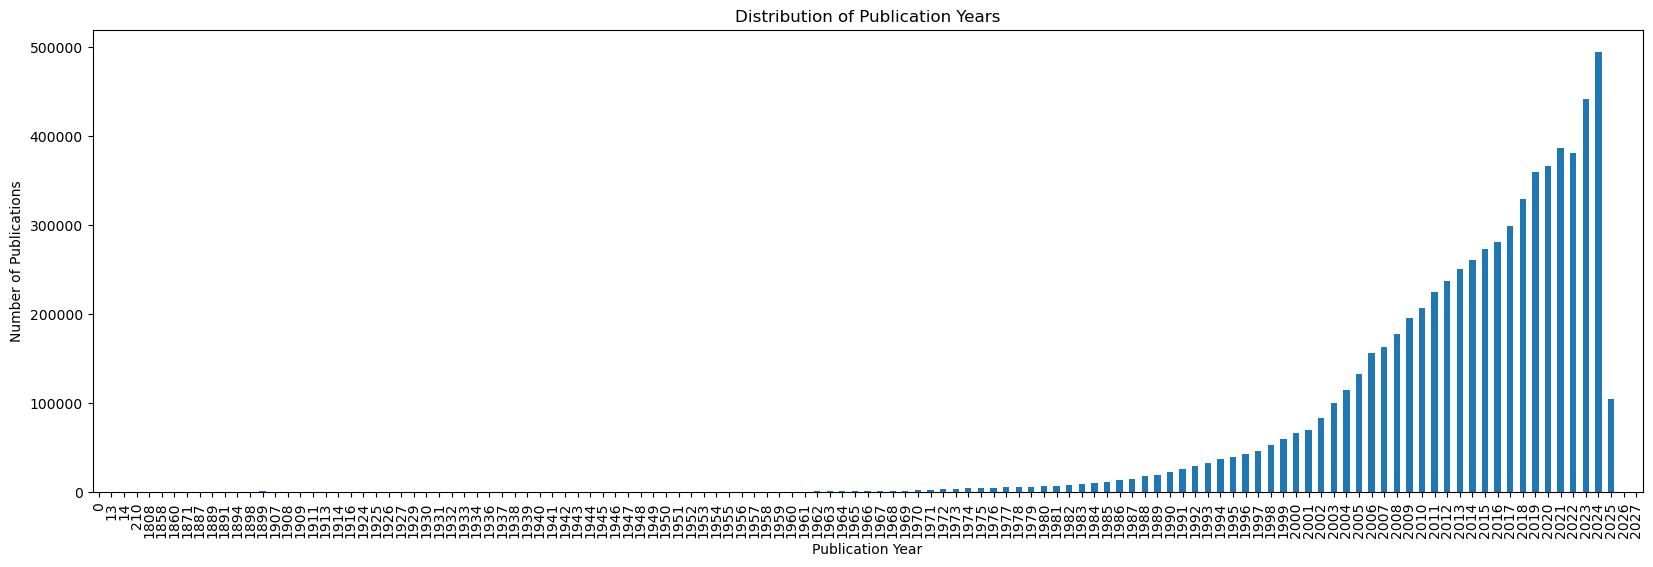

	Top 10 least common publication years:
		0) 1808: 1 occurrences
		1) 1858: 1 occurrences
		2) 1860: 1 occurrences
		3) 1871: 1 occurrences
		4) 1887: 1 occurrences
		5) 1891: 1 occurrences
		6) 1894: 1 occurrences
		7) 1907: 1 occurrences
		8) 1908: 1 occurrences
		9) 1909: 1 occurrences

	Top 10 most common publication years:
		0) 2024: 494549 occurrences
		1) 2023: 441727 occurrences
		2) 2021: 386702 occurrences
		3) 2022: 380756 occurrences
		4) 2020: 366382 occurrences
		5) 2019: 359970 occurrences
		6) 2018: 329340 occurrences
		7) 2017: 299116 occurrences
		8) 2016: 281511 occurrences
		9) 2015: 273348 occurrences

	Years with less than 100 publications:
		0: 10 occurrences
		13: 7 occurrences
		14: 4 occurrences
		210: 27 occurrences
		1808: 1 occurrences
		1858: 1 occurrences
		1860: 1 occurrences
		1871: 1 occurrences
		1887: 1 occurrences
		1889: 2 occurrences
		1891: 1 occurrences
		1894: 1 occurrences
		1898: 2 occurrences
		1907: 1 occurrences
		1908: 1 occurrences
		190

In [19]:
raw_chunks = loader.current_data.copy()
explore_year_trends(raw_chunks)

> The analysis of 'publication year' clearly shows some issues: there are records linked to future years (e.g. 2027) and to unrealistic values such as 0 or 13; some years have very few publications that are not relevant or meaningfull for our study.

Exploring distribution of missing values across columns...


Counting Missing Values in Chunks:   0%|          | 0/68 [00:00<?, ?it/s]


	Missing value counts and percentages by column:
		id: 0 missing values (0.00%)
		title: 0 missing values (0.00%)
		abstract: 0 missing values (0.00%)
		keywords: 0 missing values (0.00%)
		year: 0 missing values (0.00%)
		authors: 0 missing values (0.00%)
		references: 0 missing values (0.00%)
		page_start: 0 missing values (0.00%)
		page_end: 0 missing values (0.00%)
		lang: 0 missing values (0.00%)
		volume: 0 missing values (0.00%)
		issue: 0 missing values (0.00%)
		issn: 0 missing values (0.00%)
		isbn: 0 missing values (0.00%)
		doi: 0 missing values (0.00%)
		url: 0 missing values (0.00%)
		n_citation: 0 missing values (0.00%)
		venue: 26495 missing values (0.39%)
		doc_type: 0 missing values (0.00%)

	Columns sorted by percentage of missing values:
		venue: 26495 missing values (0.39%)
		id: 0 missing values (0.00%)
		title: 0 missing values (0.00%)
		abstract: 0 missing values (0.00%)
		keywords: 0 missing values (0.00%)
		year: 0 missing values (0.00%)
		authors: 0 missing 

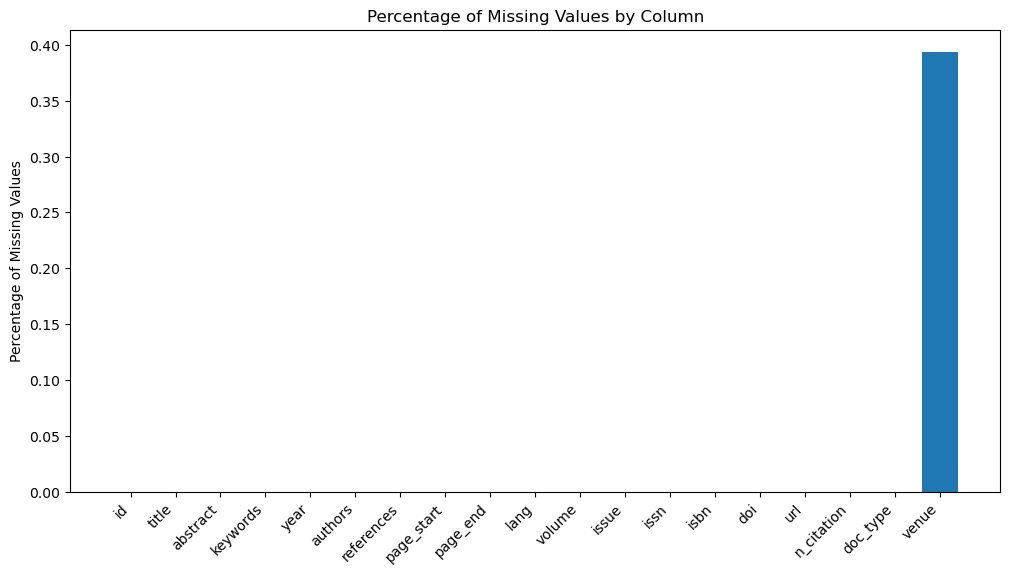

In [20]:
explore_missing_values(raw_chunks)#, not_values=NULL_PLACEHOLDERS)

> Before the cleaning step, no significant missing values are observed in the dataset.

## 2. Cleaning

### 2.1 Data Quality
Validate types and do a first cleaning:
- set all values considered as NULL_PLACEHOLDERS as NaNs
- normalise based on category type
- check the year is in a valid range
- check the doc_type has a valid category

In [ ]:
def validate_and_clean_types(df):
    """
    Validates types, cleans strings, and checks year constraints.
    """
    df = df.copy()

    # validate string and handle placeholder as NaN
    for col in STRING_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str)
            # replace placeholder strings with actual np.nan
            df[col] = df[col].replace(NULL_PLACEHOLDERS, np.nan)
    
    # validate Numeric Columns (errors='coerce' turns bad data to NaN)
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # not smaller than 0
            df.loc[(df[col] <= 0), col] = 0

    # validate Publication Year
    current_year = datetime.now().year
    # year > current year or <= 1800 -> set to NaN
    if 'year' in df.columns:
        df.loc[(df['year'] > current_year) | (df['year'] <= 1800), 'year'] = np.nan

    # normalize categorical
    if 'doc_type' in df.columns:
        # standardize to lowercase 'conference' or 'journal'
        df['doc_type'] = df['doc_type'].str.lower()
        # ensure it only contains the allowed categories
        valid_types = ['conference', 'journal']
        df.loc[~df['doc_type'].isin(valid_types), 'doc_type'] = np.nan

    # validate adn handle lists columns
    for col in ARRAY_OF_STR_COLS:
        if col in df.columns:
            placeholder = np.nan
            if col == 'references':
                # for references, we want to keep empty lists as they indicate no references, which is different from NaN (missing data)
                placeholder = np.array([], dtype='object')
            # ensure None/NaN instead of empty lists and ensure they are valid list types
            df[col] = df[col].apply(lambda x: x if isinstance(x, np.ndarray) and len(x) > 0 and x.dtype == 'O' and all(isinstance(i, str) for i in x) else placeholder)

    # validate and handle array of dictionaries columns
    for col in ARRAY_OF_DICT_COLS:
        if col in df.columns:
            # ensure None/NaN instead of empty lists and ensure they are valid list types
            df[col] = df[col].apply(lambda x: x if isinstance(x, np.ndarray) and len(x) > 0 and x.dtype == 'O' and all(isinstance(i, dict) for i in x) else np.nan)

    return df

In [22]:
valid_chunks = loader.stream_and_process(validate_and_clean_types)

if valid_chunks:
    print("Quality Check Sample (First 5 rows of first chunk):")
    display(valid_chunks[0].head(3))
    
    # count how many years were invalidated (converted to NaN)
    nan_years = valid_chunks[0]['year'].isna().sum()
    print(f"\nMissing or Invalid years in Chunk 0: {nan_years}")

Processing current internal data...


Processing Current Data Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

Quality Check Sample (First 5 rows of first chunk):


,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,NaN,"[First Page, 3-D Mechanical Object Shapes, Eng...",1984.0,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...","[5390962020f70186a0df3bf2, 5390879d20f70186a0d...",32.0,40.0,en,17.0,12.0,0018-9162,NaN,10.1109/mc.1984.1659026,NaN,46,Computer,journal
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,The UCI version of the Rand Message Handling S...,"[Computer network mail, Distributed mail syste...",1985.0,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...",[5390880720f70186a0d7a97e],65.0,80.0,en,10.0,2.0,0169-7552,NaN,10.1016/0169-7552(85)90077-7,[https://doi.org/10.1016/0169-7552(85)90077-7],4,Computer Networks and ISDN Systems,journal
2,5390877920f70186a0d2e433,Characterizing an Optimal Input in Perturbed C...,When every feasible stable perturbation of dat...,"[Optimal input, region of stability, input con...",1983.0,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...","[53e99d28b7602d97025da4e6, 5390877920f70186a0d...",109.0,121.0,en,25.0,1.0,0025-5610,NaN,10.1007/bf02591721,[https://dl.acm.org/doi/10.5555/9504.9513],20,Mathematical Programming,journal



Missing or Invalid years in Chunk 0: 1


Validating data types and applying basic cleaning rules ensure *consistency* across the dataset:
- String columns are standardised and placeholder values are converted to missing values.
- Numeric columns are coerced to valid numbers, and invalid or negative values are handled.
- Publication years outside a realistic range are removed to avoid temporal inconsistencies.
- Categorical values are normalised and restricted to valid categories only.
- List-based columns are checked to ensure they contain valid elements, while invalid or empty values are handled appropriately.
- Dictionary-based list columns are validated to keep only well-formed entries.

### 2.2a Compile Authors registry
Create and compile a df with all authors and them info

In [23]:
def tmp_authors_registry_chunks(authors_registry, chunk_size = 500_000, output_dir = "data/authors_registry_chunks"):
    """Safe checkpoints to safe the raw data of authors registry"""
    os.makedirs(output_dir, exist_ok=True)

    def convert_row(x):
        return list(x) if isinstance(x, (set, list)) else x

    def convert_org_year(x):
        if isinstance(x, (set, list)):
            return [
                [org, int(year) if pd.notna(year) else None]
                for org, year in x
            ]
        return x

    for i in tqdm(range(0, len(authors_registry), chunk_size), desc="Processing chunks"):
        chunk_id = i // chunk_size
        chunk_path = f"{output_dir}/part_{chunk_id}.parquet"

        if os.path.exists(chunk_path):
            continue

        chunk = authors_registry.iloc[i:i+chunk_size].copy()

        # conversions
        for col in ['name', 'keywords', 'lang']:
            chunk[col] = [convert_row(x) for x in chunk[col]]

        chunk['org_year'] = [convert_org_year(x) for x in chunk['org_year']]

        # safe
        chunk.to_parquet(chunk_path)

def tmp_authors_registry_merge_chunks(data_dir = "data/authors_registry_chunks", output_dir = "data/authors_registry_full.parquet"):
    """merge in an unique parquet file"""
    files = sorted(glob.glob(f"{data_dir}/part_*.parquet"))

    writer = None

    for f in tqdm(files, desc="Merging chunks"):
        table = pq.read_table(f)

        if writer is None:
            writer = pq.ParquetWriter(
                output_dir,
                table.schema
            )

        writer.write_table(table)

    if writer:
        writer.close()

    print("Merge completed!")

def safe_authors_registry_raw_checkpoint(authors_registry, chunk_size = 500_000, chunks_dir="data/authors_registry_chunks", output_dir="data/authors_registry_full.parquet"):
    tmp_authors_registry_chunks(authors_registry, chunk_size=chunk_size, output_dir=chunks_dir)
    tmp_authors_registry_merge_chunks(data_dir=chunks_dir, output_dir=output_dir)

This step saves the authors registry in temporary Parquet chunks to avoid memory issues during processing.

Each chunk is converted to a consistent format and written only if it does not already exist.

After chunking, all partial files are merged into a single Parquet file.

In [ ]:
from collections import Counter 
import ast

def is_valid_name(name):
    # ^ : start of the string
    # [A-Za-z\s]+ : one or more letters (upper or lower case) or whitespace characters
    # $ : end of the string
    return bool(re.match(r'^[A-Za-z\s]+$', name))

def union_sets(series):
        return set().union(*series)

def union_org_year(series):
    unique_orgs = set()
    for sublist in series:
        if isinstance(sublist, (list, set)):
            for item in sublist:
                if isinstance(item, (list, tuple)):
                    unique_orgs.add(item)
                elif isinstance(item, dict) and 'org' in item and 'year' in item:
                    unique_orgs.add((item['org'], item['year']))
    return list(unique_orgs.values())

def extract_author_info(df):
    """
    Extract authors' info from a chunk of papers
    """
    author_records = []

    for _, row in df.iterrows():
        authors_list = row.get('authors')
        # print(f'debug 1: {len(authors_list)}')
        
        # if not isinstance(authors_list, list):
        #     continue

        if isinstance(authors_list, str):
            try:
                authors_list = ast.literal_eval(authors_list)
            except:
                continue
            
        keywords = set(row.get('keywords')) if isinstance(row.get('keywords'), list) else set()
        lang = row.get('lang')
        year = row.get('year')
        # print(f'\tdebug 2: {lang}, {year}')

        for auth in authors_list:
            auth_id = auth.get('id')
            auth_name = auth.get('name')
            auth_org = auth.get('org')
            # print(f'\t\tdebug 3: {auth_id}, {auth_name}, {auth_org}')

            # id is the primary key otherwise the name
            has_id = bool(auth_id and auth_id != '')
            key = auth_id if has_id else auth_name
            if not key: 
                continue
            # print(f'\t\t\tdebug 4:{has_id}, {key}')

            author_records.append({
                'id_or_name': key,
                'is_id': has_id,
                'name': [auth_name] if auth_name else list(),
                'org_year': {(auth_org, year)} if auth_org and not pd.isna(year) else set(),
                'keywords': keywords,
                'lang': {lang} if lang and not pd.isna(lang) else set()
            })

    # create a temp dataframe with chunk's info
    if not author_records:
        return pd.DataFrame()

    temp_df = pd.DataFrame(author_records)
    
    # chunk aggregation
    return temp_df.groupby('id_or_name').agg({
        'name': 'sum',
        'is_id': 'max',
        'org_year': union_org_year,
        'keywords': union_sets,
        'lang': union_sets
    }).reset_index()


def assigns_ids(df):
    """Assign an ID to authors that don't have it, based on their official name."""
    # mapping official_name to ID
    name_to_id = df[df['is_id'] == True].explode('official_name').set_index('official_name')['id_or_name'].to_dict()

    # assign IDs to authors without an ID based on their official name
    def assign_name_to_id(row):
        if not row['is_id'] and isinstance(row['official_name'], str) and row['official_name']:
            if row['official_name'] in name_to_id:
                return name_to_id[row['official_name']]
        return row['id_or_name'] if row['is_id'] else None

    df['id'] = df.apply(assign_name_to_id, axis=1)
    return df

def assign_official_name(df):
    """Assign an official name to each author based on the most common name used."""
    def most_common_name(names):
        if isinstance(names, list) and names:
            return Counter(names).most_common(1)[0][0]
        return None

    df['official_name'] = df['name'].apply(most_common_name)
    return df

def clean_names(df):
    """Clean the names by removing invalid entries."""
    def filter_names(names):
        # keep only valid names (alphabets and spaces)
        return [name for name in names if isinstance(name, str) and is_valid_name(name)]
    
    df['name'] = df['name'].apply(filter_names)
    return df

def clean_org_year(df):
    """Clean the org_year column to ensure it's in the correct format."""
    def clean_org_year_item(org_year):
        if isinstance(org_year, (set, list)):
            cleaned = []
            for item in org_year:
                if isinstance(item, (list, tuple)) and len(item) == 2:
                    org, year = item
                    cleaned.append((org, int(year) if pd.notna(year) else None))
                elif isinstance(item, dict) and 'org' in item and 'year' in item:
                    cleaned.append((item['org'], int(item['year']) if pd.notna(item['year']) else None))
            return cleaned
        return org_year

    df['org_year'] = df['org_year'].apply(clean_org_year_item)
    return df

def safe_authors_registry(df, path=AUTH_REGISTRY_PATH):
    """Save the refined authors registry to a parquet file."""
    df.drop(columns=['is_id', 'id_or_name']).to_parquet(path)
    print(f"Authors registry saved to {path}")    

def refine_authors_df(df):
    """ 
    refine the df of authors:
    - assign an id to the one that don't have it
    - assign an unique name ('official_name') based on the most used one
    and save the df as a parquet
    """
    tqdm.pandas(desc="Refining Authors DataFrame")
    # df = df.pipe(assigns_ids).pipe(assign_official_name).pipe(clean_org_year)
    print("\tCleaning the names...")
    df = clean_names(df)
    print("\tCleaning the organization and year information...")
    df = clean_org_year(df)
    print("\tAssigning official names...")
    df = assign_official_name(df)
    print("\tAssigning IDs...")
    df = assigns_ids(df)

    safe_authors_registry(df)
    return df


This stage builds and refines the authors registry in a safe and incremental way where:
- author information is extracted from the dataset, aggregated across chunks, and periodically saved to avoid memory issues.
- names, affiliations, keywords, and languages are merged and cleaned to remove inconsistencies.
- assign an *official author name* based on usage frequency.
- final registry is normalised, converted to a Parquet‑compatible format, and saved for downstream analysis.

In [25]:
if not os.path.exists(AUTH_REGISTRY_PATH):
    if not os.path.exists(RAW_AUTH_REGISTRY_PATH):
        # extract the info
        author_chunks = loader.stream_and_process(extract_author_info, update_internal=False, take_current=True)

        # aggregate info
        print("Authors aggregation in progress...")
        authors_registry = None

        for chunk in author_chunks:
            if chunk.empty:
                continue
            if authors_registry is None:
                authors_registry = chunk
            else:
                authors_registry = pd.concat([authors_registry, chunk], ignore_index=True)
            authors_registry = authors_registry.groupby('id_or_name').agg({
                'is_id': 'max',
                'name': 'sum',
                'org_year': union_org_year,
                'keywords': union_sets,
                'lang': union_sets
            }).reset_index()

            safe_authors_registry_raw_checkpoint(authors_registry=authors_registry)
    else:
        print(f'Read and import file authors raw data from: {RAW_AUTH_REGISTRY_PATH}')
        authors_registry = pd.read_parquet(RAW_AUTH_REGISTRY_PATH)

    print(f"Found {len(authors_registry)} unique authors.")

    # refine the dataframe
    print("Authors refining in progress...")
    final_authors_registry = refine_authors_df(authors_registry)

    # conver set in lists and save it
    reg_to_save = final_authors_registry.copy()

    for col in ['name', 'keywords', 'lang']:
        reg_to_save[col] = [list(x) if isinstance(x, (set, list)) else x for x in reg_to_save[col]]
        # reg_to_save[col].apply(lambda x: list(x) if isinstance(x, (set, list)) else x)

    reg_to_save['org_year'] = [
        [{"org": org, "year": int(year) if pd.notna(year) else None} for org, year in x] 
        if isinstance(x, (set, list)) else x for x in reg_to_save['org_year']
    ]
    reg_to_save.drop(columns=['is_id']).to_parquet(AUTH_REGISTRY_PATH)
else: 
    print(f'Read and import file from: {AUTH_REGISTRY_PATH}')
    final_authors_registry = pd.read_parquet(AUTH_REGISTRY_PATH)

Read and import file from: data/authors_registry.parquet


If no previous authors registry is found, author information is extracted incrementally from the papers dataset.


Author data is aggregated across chunks to merge names, affiliations, keywords, and languages.


The raw aggregated registry is saved periodically to ensure fault tolerance.

In [26]:
display(final_authors_registry[final_authors_registry['id'].isna()].head(3))
display(final_authors_registry[final_authors_registry['id'].notna()].head(3))

,id_or_name,name,org_year,keywords,lang,official_name,id
0,\nHelmut Klemm freier Journalist,[\nHelmut Klemm freier Journalist],"[{'org': 'Würzburg', 'year': 2003}]",[],[en],\nHelmut Klemm freier Journalist,NaN
1,,"[ , , , , , , , , , , , , , , , ...",[{'org': 'Defence Science and Technology Group...,[],[en],,NaN
2,,"[ , , , , ]",[{'org': 'Institute of Mathematics University ...,[],[en],,NaN


,id_or_name,name,org_year,keywords,lang,official_name,id
100,Sharmila,[ Sharmila],[],[],[],Sharmila,64036385adc7183bcb77e117
179,53f3186ddabfae9a84425c58,"[H Ancin, Hakan Ancin, H Ancin, H Ancin, Hakan...","[{'org': 'RENSSELAER POLYTECH INST,DEPT ELECT ...",[],[en],H Ancin,53f3186ddabfae9a84425c58
180,53f3186fdabfae9a84425cde,[],"[{'org': 'king abdulaziz university', 'year': ...",[],[en],NaN,53f3186fdabfae9a84425cde


### 2.2b Assign missing author's id, name and org
- Assign the id to the authors without id, based on the official name assigned.
- Assign the name to the authors without name, based on the id and official name assigned (most used name).
- Assign an org to the authors without org, based on the author id and on the year of publication.

In [27]:
loader.current_data[0].head(3)

,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,NaN,"[First Page, 3-D Mechanical Object Shapes, Eng...",1984.0,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...","[5390962020f70186a0df3bf2, 5390879d20f70186a0d...",32.0,40.0,en,17.0,12.0,0018-9162,NaN,10.1109/mc.1984.1659026,NaN,46,Computer,journal
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,The UCI version of the Rand Message Handling S...,"[Computer network mail, Distributed mail syste...",1985.0,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...",[5390880720f70186a0d7a97e],65.0,80.0,en,10.0,2.0,0169-7552,NaN,10.1016/0169-7552(85)90077-7,[https://doi.org/10.1016/0169-7552(85)90077-7],4,Computer Networks and ISDN Systems,journal
2,5390877920f70186a0d2e433,Characterizing an Optimal Input in Perturbed C...,When every feasible stable perturbation of dat...,"[Optimal input, region of stability, input con...",1983.0,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...","[53e99d28b7602d97025da4e6, 5390877920f70186a0d...",109.0,121.0,en,25.0,1.0,0025-5610,NaN,10.1007/bf02591721,[https://dl.acm.org/doi/10.5555/9504.9513],20,Mathematical Programming,journal


In [28]:
loader.current_data[0].iloc[0:3][['year', 'authors']]

,year,authors
0,1984.0,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H..."
1,1985.0,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {..."
2,1983.0,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S..."


In [29]:
chunks_filled = loader.fill_author_gaps(final_authors_registry)

Creating mapping dictionaries from the authors registry...
	name to official name mapping...
	id to official name mapping...
	official name to id mapping...
	id-year to org mapping...


Filling Authors Gaps Chunks::   0%|          | 0/68 [00:00<?, ?it/s]

### 2.3 Correct the venue mismatches
- when there is 'Conference' in venue name, but 'Journal' in doc_type
- when there is 'Journal' in venue name, but 'Conference' in doc_type

In [30]:
chunks_cleaned = loader.fix_venue_mismatch(chunks_filled)

Fixing Venue Mismatch Chunks::   0%|          | 0/68 [00:00<?, ?it/s]

Found and fixed 83983 mismatches where 'Conference' is in venue but doc_type is 'Journal'.
Found and fixed 20086 mismatches where 'Journal' is in venue but doc_type is 'Conference'.
Found and fixed 389 mismatches where 'Conference' is in venue but doc_type is missing.
Found and fixed 23 mismatches where 'Journal' is in venue but doc_type is missing.


### 2.4 Validate the References
A paper cannot add as a reference:
- a future paper
- invalid paper id


In [31]:
# id_to_year = ids_registry.set_index('id')['year'].to_dict()
id_to_year = {str(k): v for k, v in ids_registry.set_index('id')['year'].to_dict().items()}

In [32]:
def validate_reference(references, paper_year, id_to_year=id_to_year, placeholder=''):
    """Validate the 'references' field to ensure it contains valid IDs."""
    if placeholder == '':
        placeholder = []

    # ensure paper_year is a valid number before proceeding with reference validation
    if not isinstance(paper_year, (int, float)) or pd.isna(paper_year):
        return references if isinstance(references, (list, np.ndarray)) and len(references) > 0 else placeholder
    paper_year = float(paper_year)  # ensure it's a float for comparison
    
    # ensure references is a valid list or array of strings
    if not isinstance(references, (list, np.ndarray)):
        if pd.isna(references):
            print(f'reference is {references} and is treated as NaN')
        else:
            print(f'Invalid type for references: {type(references)}: {references}')
        return placeholder
    # ensure it's full and not empty
    if len(references) == 0:
        return placeholder
    
    
    valid_references = []
    for ref in references:
        ref_str = str(ref)  # ensure the reference ID is a string for consistent lookup
        # get year if the ref is in the registry
        ref_year = id_to_year.get(ref_str)

        if ref_year is not None: # and ref_year in id_to_year.keys() is redundenat, verify it exist and is valid
            if ref_year <= paper_year:  # check if the reference is from the past
                valid_references.append(ref)

    return valid_references if valid_references else placeholder
    # otherwise, if it's not a valid array of strings, treat it as missing
    

def clean_references(df, id_to_year=id_to_year):
    """Clean the 'references' field in the DataFrame."""
    df = df.copy()
    df['references'] = df.apply(
        lambda row: validate_reference(row['references'], row['year'], id_to_year=id_to_year), 
        axis=1
    )
    return df

In [33]:
chunks_cleaned = loader.stream_and_process(clean_references, update_internal=True, take_current=True, id_to_year=id_to_year)

Processing current internal data...


Processing Current Data Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

### #01.Checkpoint : cleaned data

In [34]:
if SAVE_CHECKPOINTS:
    CK01_PATH = os.path.join(CHECKPOINTS_PATH, "01_cleaned_data")
    loader.safe_checkpoint(base_name='01_cleaned_data', path=CK01_PATH, chunk_size=100_000)

## 3. Exploration after cleaning

### of the first 1000 lines in chunk 0

In [35]:
cleaned_chunk_0 = chunks_cleaned[0].head(1000)
cleaned_global_df = global_inspection(cleaned_chunk_0)

Global DataFrame Description:


,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
num_nan,0,0,68,264,0,0,0,3230,3943,237,10746,12848,8771,17006,550,3844,0,203,0
num_not_nan,17801,17801,17733,17537,17801,17801,17801,14571,13858,17564,7055,4953,9030,795,17251,13957,17801,17598,17801
count,17801,17801,17733,17537,17801.0,17801,17801,14571.0,13858.0,17564,7055.0,4953.0,9030,795,17251,13957,17801.0,17598,17801
unique,1000,1000,978,5743,NaN,2812,849,NaN,NaN,1,NaN,NaN,263,23,974,821,NaN,780,2
top,5390a45620f70186a0e733d1,LAHVA: Linked Animal-Human Health Visual Analy...,Coordinated animal-human health monitoring can...,proposed method,NaN,"{'id': '53f38e3edabfae4b34a44248', 'name': 'Ki...",[],NaN,NaN,en,NaN,NaN,0302-9743,978-0-7695-3877-8,10.1109/vast.2007.4388993,[https://www.semanticscholar.org/paper/afbe068...,NaN,Lecture notes in computer science,conference
freq,190,190,190,22,NaN,32,1761,NaN,NaN,17564,NaN,NaN,2337,128,190,190,NaN,350,11885
mean,NaN,NaN,NaN,NaN,2005.209932,NaN,NaN,721.635989,580.69339,NaN,667.602551,4.506562,NaN,NaN,NaN,NaN,74.790068,NaN,NaN
std,NaN,NaN,NaN,NaN,6.838024,NaN,NaN,4188.992097,2760.207705,NaN,1636.061364,3.372117,NaN,NaN,NaN,NaN,456.779179,NaN,NaN
min,NaN,NaN,NaN,NaN,1959.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25%,NaN,NaN,NaN,NaN,2003.0,NaN,NaN,121.0,135.0,NaN,15.0,2.0,NaN,NaN,NaN,NaN,7.0,NaN,NaN


In [36]:
raw_global_df.head()

,id,title,abstract,keywords,year,authors,references,page_start,page_end,lang,volume,issue,issn,isbn,doi,url,n_citation,venue,doc_type
num_nan,0,0,0,264,0,0,0,0,0,0,0,0,0,0,0,0,0,201,0
num_not_nan,17801,17801,17801,17537,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17600,17801
count,17801,17801,17801,17537,17801.0,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801,17801.0,17600,17801
unique,1000,1000,979,5743,NaN,2812,1000,576,586,2,158,38,264,24,975,1000,NaN,781,2
top,5390a45620f70186a0e733d1,LAHVA: Linked Animal-Human Health Visual Analy...,Coordinated animal-human health monitoring can...,proposed method,NaN,"{'id': '53f38e3edabfae4b34a44248', 'name': 'Ki...","[53e9a2b3b7602d9702bbdcc3, 53e9a789b7602d97030...",,,en,,,,,,[https://www.semanticscholar.org/paper/afbe068...,NaN,Lecture notes in computer science,Conference


In [37]:
inspect_authors_field(cleaned_chunk_0)
print()

Inspecting 'authors' field for potential issues...
	Number of NaN values in 'authors': 0
	Number of entries with invalid structure in 'authors': 0
	Number of empty array entries in 'authors': 0
	Number of unique authors in 'authors': 2787



In [38]:
inspect_keywords_field(cleaned_chunk_0)
print()

Inspecting 'keywords' field for potential issues...
	Number of NaN values in 'keywords': 98
	Number of empty array entries in 'keywords': 0
	Number of entries with invalid structure in 'keywords': 98
	Number of unique keywords: 5743
	Average number of keywords per paper: 6.02
	Max number of keywords for a single paper: 32
	Top 10 most common keywords:
		0) proposed method: 8 occurrences
		1) data mining: 7 occurrences
		2) clustering: 7 occurrences
		3) data structure: 6 occurrences
		4) scheduling: 6 occurrences
		5) neural network: 6 occurrences
		6) new method: 6 occurrences
		7) ontology: 6 occurrences
		8) quality of service: 5 occurrences
		9) optimization: 5 occurrences



> After cleaning the 'keywords' feature, empty arrays are converted to NaN values, as they represent invalid structures that will be handled later.

In [39]:
inspect_venue_field(cleaned_chunk_0)
print()

Inspecting 'venue' field for potential issues...
	Number of NaN values in 'venue': 9
	Number of unique venues: 780
	Top 10 most common venues:
		0) Lecture notes in computer science: 13 occurrences
		1) Automatica: 8 occurrences
		2) Theoretical Computer Science: 7 occurrences
		3) Bioinformatics: 7 occurrences
		4) IEEE Transactions on Information Theory: 7 occurrences
		5) Signal Processing: 6 occurrences
		6) IEEE Transactions on Signal Processing: 6 occurrences
		7) Computer: 5 occurrences
		8) IEEE Transactions on Computers: 5 occurrences
		9) Computer Communications: 5 occurrences



> The same approach of 'keywords' is applied to the 'venue' feature.

In [40]:
inspect_doc_type_field(cleaned_chunk_0)

Inspecting 'doc_type' field for potential issues...
	Number of NaN values in 'doc_type': 0
	Number of unique doc types: 2
	Top 10 most common doc types:
		0) conference: 563 occurrences
		1) journal: 437 occurrences


> For the 'doc_type' feature, no missing values are present after cleaning, since all entries are imputed and restricted to the two valid classes.

In [41]:
inspect_year_field(cleaned_chunk_0)

Inspecting 'year' field for potential issues...
	Number of NaN values in 'year': 0
	Number of invalid years (<=1800 or >2026): 0
	Top 10 most common publication years:
		0) 2009.0: 105 occurrences
		1) 2011.0: 79 occurrences
		2) 2010.0: 79 occurrences
		3) 2006.0: 76 occurrences
		4) 2012.0: 74 occurrences
		5) 2007.0: 73 occurrences
		6) 2008.0: 73 occurrences
		7) 2005.0: 64 occurrences
		8) 2004.0: 42 occurrences
		9) 2003.0: 35 occurrences


In [42]:
print('Before cleaning')
inspect_references_field(raw_chunks[0], id_to_year, example=False)
print('-'*100)
print('After cleaning')
inspect_references_field(chunks_cleaned[0], id_to_year, example=False)

Before cleaning
Inspecting 'references' field for potential issues...
	Number of NaN values in 'references': 0
	Number of empty array entries in 'references': 15807
	Number of entries with invalid structure (excluding NaN) in 'references': 0
	Number of references newer than the paper itself: 10821
----------------------------------------------------------------------------------------------------
After cleaning
Inspecting 'references' field for potential issues...
	Number of NaN values in 'references': 0
	Number of empty array entries in 'references': 0
	Number of entries with invalid structure (excluding NaN) in 'references': 0
	Number of references newer than the paper itself: 0


> References to papers published in the future are removed.

### global exploration after

Exploring yearly trends in publication data...


Extracting Years from Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

	Publication counts by year:


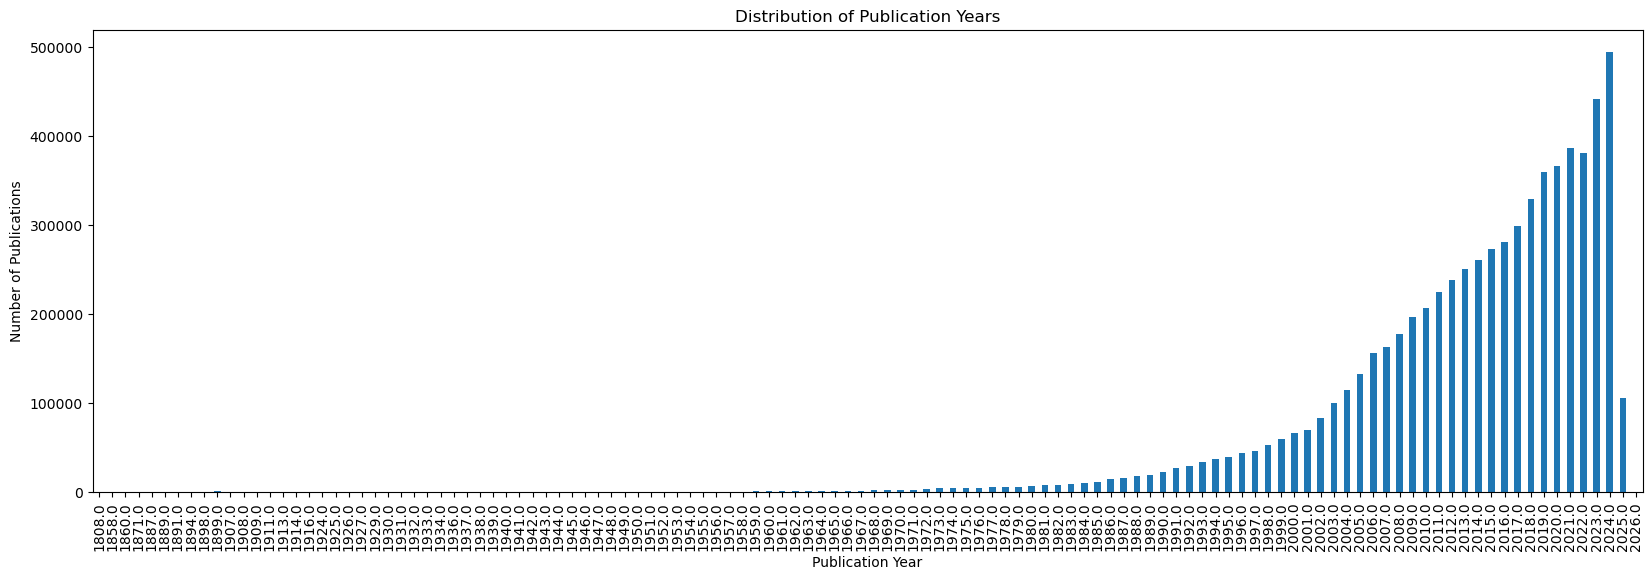

	Top 10 least common publication years:
		0) 1808.0: 1 occurrences
		1) 1858.0: 1 occurrences
		2) 1860.0: 1 occurrences
		3) 1871.0: 1 occurrences
		4) 1887.0: 1 occurrences
		5) 1891.0: 1 occurrences
		6) 1894.0: 1 occurrences
		7) 1907.0: 1 occurrences
		8) 1908.0: 1 occurrences
		9) 1909.0: 1 occurrences

	Top 10 most common publication years:
		0) 2024.0: 494549 occurrences
		1) 2023.0: 441727 occurrences
		2) 2021.0: 386702 occurrences
		3) 2022.0: 380756 occurrences
		4) 2020.0: 366382 occurrences
		5) 2019.0: 359970 occurrences
		6) 2018.0: 329340 occurrences
		7) 2017.0: 299116 occurrences
		8) 2016.0: 281511 occurrences
		9) 2015.0: 273348 occurrences

	Years with less than 100 publications:
		1808.0: 1 occurrences
		1858.0: 1 occurrences
		1860.0: 1 occurrences
		1871.0: 1 occurrences
		1887.0: 1 occurrences
		1889.0: 2 occurrences
		1891.0: 1 occurrences
		1894.0: 1 occurrences
		1898.0: 2 occurrences
		1907.0: 1 occurrences
		1908.0: 1 occurrences
		1909.0: 1 occurrences
	

In [43]:
explore_year_trends(chunks_cleaned)

> From the global distribution of publication years, we can see that invalid years identified before cleaning have been corrected or removed.

Exploring distribution of missing values across columns...


Counting Missing Values in Chunks:   0%|          | 0/68 [00:00<?, ?it/s]


	Missing value counts and percentages by column:
		id: 0 missing values (0.00%)
		title: 0 missing values (0.00%)
		abstract: 361893 missing values (5.38%)
		keywords: 1090024 missing values (16.20%)
		year: 49 missing values (0.00%)
		authors: 3 missing values (0.00%)
		references: 0 missing values (0.00%)
		page_start: 1839622 missing values (27.34%)
		page_end: 1997890 missing values (29.69%)
		lang: 242582 missing values (3.60%)
		volume: 3467418 missing values (51.52%)
		issue: 4585067 missing values (68.13%)
		issn: 3104516 missing values (46.13%)
		isbn: 6646602 missing values (98.76%)
		doi: 601990 missing values (8.95%)
		url: 501646 missing values (7.45%)
		n_citation: 0 missing values (0.00%)
		venue: 44905 missing values (0.67%)
		doc_type: 20632 missing values (0.31%)

	Additional values treated as missing:
		None: 0 occurrences across all columns
		nan: 0 occurrences across all columns
		NaN: 0 occurrences across all columns
		N/A: 0 occurrences across all columns
		: 0 

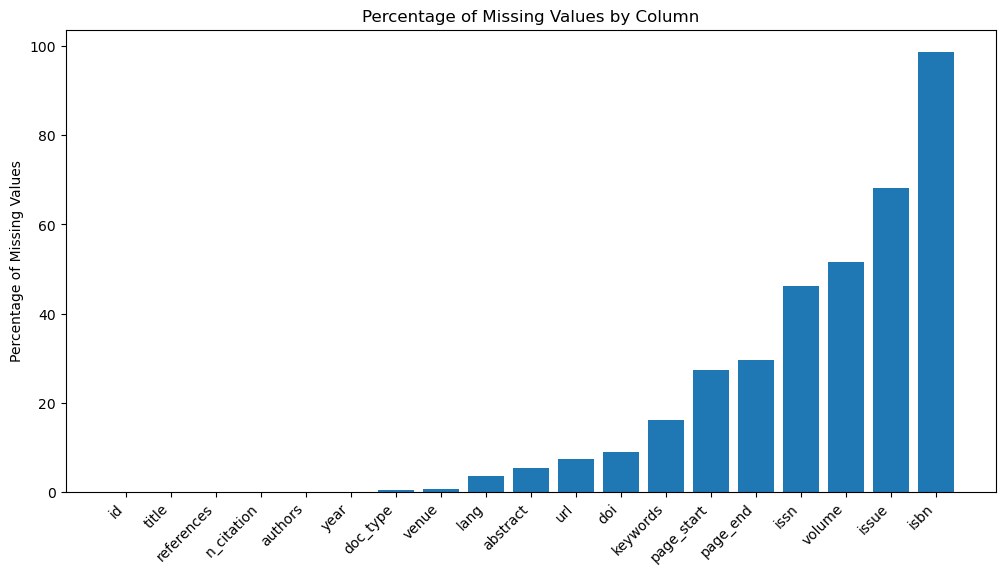

In [44]:
explore_missing_values(chunks_cleaned, not_values=NULL_PLACEHOLDERS)

> The number of missing values increases after cleaning because empty arrays and invalid values are converted to NaNs. In particular, the features isbn, issue, volume, and issn show a high percentage of missing values (50% or more).

## 4. Feature Selection

### 4.1 remove non meaningfull features

In [45]:
# if we remove page_start and page_end, we will lose the possibility to calculate the number of pages, which can be a useful feature for some analysis, so we add it before removing the columns
def add_n_pages(df):
    """Add a new column 'n_pages' to the DataFrame, calculated as page_end - page_start + 1."""
    df = df.copy()
    df['n_pages'] = (df['page_end'] - df['page_start'] + 1).where(df['page_end'].notna() & df['page_start'].notna(), np.nan)
    return df

In [46]:
# remove_columns = lambda df, cols: df.drop(columns=[col for col in cols if col in df.columns], axis=1) if cols in df.columns else df
def remove_columns(df, cols):
    return df.drop(columns=[c for c in cols if c in df.columns], errors="ignore")

# remove isbn and issn because they have a lot of missing values and they are not crucial for our analysis
unnecessary_cols = ['isbn', 'issn']
# remove issue and volume because they are not crucial and have a lot of missing values
unnecessary_cols += ['issue', 'volume']
# remove page_start and page_end because they are not crucial and have a lot of missing values
loader.stream_and_process(add_n_pages, update_internal=True, take_current=True) # we need to add n_pages before removing page_start and page_end
unnecessary_cols += ['page_start', 'page_end']
# remove id because it's an unique identifier, but we need it to testing the function
# unnecessary_cols += ['id']

feature_selected_chunks = loader.stream_and_process(remove_columns, cols=unnecessary_cols, update_internal=True, take_current=True)

Processing current internal data...


Processing Current Data Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

Processing current internal data...


Processing Current Data Chunks:   0%|          | 0/68 [00:00<?, ?it/s]

### #02.Checkpoint: feature selection

In [47]:
# export the cleaned data to parquet files in chunks
if SAVE_CHECKPOINTS:
    CK02_PATH = os.path.join(CHECKPOINTS_PATH, "02_feature_selection_data")
    loader.safe_checkpoint(base_name='02_feature_selection_data', path=CK02_PATH, chunk_size=100_000)

## 5. Export the final cleaned parquets divided by year

In [48]:
loader.safe_checkpoint(base_name='year', path=CLEANED_DATA_PATH, mode_divide_by='year')

# remove files with insufficient data (e.g., years with less than 100 publications)
for f in glob.glob(f"{CLEANED_DATA_PATH}/year_*.parquet"):
    year = f.split("_")[-1].split(".")[0]
    if int(year) <= 1970:
        os.remove(f)
        print(f"Removed file for year {year} due to insufficient data.")

Retrieving PyArrow schema for checkpointing...

Generated PyArrow schema for checkpointing: 
id: string
title: string
lang: string
doc_type: string
venue: string
doi: string
abstract: string
year: double
n_citation: double
references: list<item: string>
  child 0, item: string
keywords: list<item: string>
  child 0, item: string
url: list<item: string>
  child 0, item: string
authors: list<item: struct<id: string, name: string, org: string>>
  child 0, item: struct<id: string, name: string, org: string>
      child 0, id: string
      child 1, name: string
      child 2, org: string

Saving checkpoint with 6729828 records...


Saving Parquet Files by Value:   0%|          | 0/118 [00:00<?, ?it/s]

Checkpoint saved to data/cleaned_parquet with files divided by year.
Removed file for year 1808 due to insufficient data.
Removed file for year 1858 due to insufficient data.
Removed file for year 1860 due to insufficient data.
Removed file for year 1871 due to insufficient data.
Removed file for year 1887 due to insufficient data.
Removed file for year 1889 due to insufficient data.
Removed file for year 1891 due to insufficient data.
Removed file for year 1894 due to insufficient data.
Removed file for year 1898 due to insufficient data.
Removed file for year 1899 due to insufficient data.
Removed file for year 1907 due to insufficient data.
Removed file for year 1908 due to insufficient data.
Removed file for year 1909 due to insufficient data.
Removed file for year 1911 due to insufficient data.
Removed file for year 1913 due to insufficient data.
Removed file for year 1914 due to insufficient data.
Removed file for year 1916 due to insufficient data.
Removed file for year 1924 due